# Task 1: Algorithmic Analysis K-Means Clustering with Real World Dataset 

In [1]:
import numpy as np
import pandas as pd
import time
from scipy.stats import mode

data = pd.read_csv('/scratch/hdharmen/CSE572/kmeans_data/data.csv', header=None).values.astype(float)
labels = pd.read_csv('/scratch/hdharmen/CSE572/kmeans_data/label.csv', header=None).values.flatten()

K = len(np.unique(labels))   # K = 10
print(f"Data shape: {data.shape}, K={K}")

Data shape: (10000, 784), K=10


In [2]:
# Euclidean, Cosine, Jaccard distance functions with batch support
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))

def euclidean_batch(point, centroids):
    return euclidean_distance(point, centroids)

def cosine_distance(a, b):
    dot = np.dot(b, a)                         
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b, axis=1)
    denom = norm_b * norm_a
    denom = np.where(denom == 0, 1e-10, denom)
    return 1 - dot / denom

def cosine_batch(point, centroids):
    return cosine_distance(point, centroids)

def jaccard_distance(a, b):
    min_sum = np.sum(np.minimum(b, a), axis=1)
    max_sum = np.sum(np.maximum(b, a), axis=1)
    denom = np.where(max_sum == 0, 1e-10, max_sum)
    return 1 - min_sum / denom

def jaccard_batch(point, centroids):
    return jaccard_distance(point, centroids)


In [3]:
# K-means implementation from scratch
def kmeans(data, K, dist_fn, max_iter=500, seed=42):
    rng = np.random.default_rng(seed)     # random initialisation
    indices = rng.choice(len(data), K, replace=False)
    centroids = data[indices].copy()

    prev_sse = np.inf
    iterations = 0

    for i in range(max_iter):
        iterations += 1
        dists = np.array([dist_fn(data[j], centroids) for j in range(len(data))]) # distance between each point and centers
        cluster_ids = np.argmin(dists, axis=1)
        
        # compute SSE
        sse = sum(
            np.sum((data[cluster_ids == k] - centroids[k]) ** 2)
            for k in range(K)
            if np.any(cluster_ids == k)
        )

        # update centroids
        new_centroids = np.array([
            data[cluster_ids == k].mean(axis=0) if np.any(cluster_ids == k) else centroids[k]
            for k in range(K)
        ])

        # stopping conditions
        no_change = np.allclose(centroids, new_centroids, atol=1e-6)
        sse_increased = sse > prev_sse

        centroids = new_centroids
        prev_sse = sse

        if no_change or sse_increased:
            break

    return cluster_ids, centroids, sse, iterations

### Task 1.1: Running K-means clustering with Euclidean, Cosine and Jarcard similarity. Specifying K = 10, the number of categorical values of y and comparing the SSEs of Euclidean-K-means, Cosine-K-means, Jarcard-K-means. 

In [4]:
results = {}
for name, fn in [('Euclidean', euclidean_batch),
                 ('Cosine',    cosine_batch),
                 ('Jaccard',   jaccard_batch)]:
    print(f"\n{name}-KMeans")
    t0 = time.time()
    cluster_ids, centroids, sse, iters = kmeans(data, K, fn)
    elapsed = time.time() - t0
    results[name] = {'cluster_ids': cluster_ids, 'centroids': centroids, 'sse': sse, 'iters': iters, 'time': elapsed}
    print(f"  SSE={sse:.2f}  |  Iterations={iters}  |  Time={elapsed:.1f}s")

print("\nTask 1.1: SSE Comparison")
print(f"{'Method':<12} {'SSE':>20} {'Iterations':>12} {'Time(s)':>10}")
print("-" * 58)
for name, r in results.items():
    print(f"{name:<12} {r['sse']:>20.2f} {r['iters']:>12} {r['time']:>10.1f}")

best = min(results, key=lambda x: results[x]['sse'])
print(f"\nBest method (lowest SSE): {best}")


Euclidean-KMeans
  SSE=25466788154.49  |  Iterations=39  |  Time=9.2s

Cosine-KMeans
  SSE=25488154937.17  |  Iterations=29  |  Time=7.8s

Jaccard-KMeans
  SSE=25520780560.28  |  Iterations=19  |  Time=7.6s

Task 1.1: SSE Comparison
Method                        SSE   Iterations    Time(s)
----------------------------------------------------------
Euclidean          25466788154.49           39        9.2
Cosine             25488154937.17           29        7.8
Jaccard            25520780560.28           19        7.6

Best method (lowest SSE): Euclidean


Answer: Euclidean-KMeans produces the lowest SSE and is therefore the best method. 
- Since Euclidean distance directly measures the geometric distance between data points in feature space, it works great for minimizing within-cluster
variance. 
- Cosine distance captures angular similarity and ignores magnitude. Jaccard distance measures feature overlap. These two are both less effective at minimizing cluster compactness on this dataset.

### Task 1.2: Comparing accuracies of Euclidean-K-means Cosine-K-means, Jarcard-K-means. First, labelling each cluster using the majority vote label of the data points in that cluster. Later, computing the predictive accuracy of Euclidean-K-means, Cosine-K-means, Jarcard-K-means.

In [5]:
# compute majority vote accuracy for the best method
def majority_vote_accuracy(cluster_ids, true_labels, K):
    predicted_labels = np.zeros_like(true_labels)

    for k in range(K):
        mask = cluster_ids == k
        if not np.any(mask):
            continue
        # Majority label in this cluster
        majority_label = mode(true_labels[mask], keepdims=True).mode[0]
        predicted_labels[mask] = majority_label

    accuracy = np.mean(predicted_labels == true_labels)
    return accuracy

In [6]:
print("Task 1.2: Accuracy Comparison")
print(f"{'Method':<12} {'SSE':>20} {'Accuracy':>10}")
print("-" * 45)

for name, r in results.items():
    acc = majority_vote_accuracy(r['cluster_ids'], labels, K)
    results[name]['accuracy'] = acc
    print(f"{name:<12} {r['sse']:>20.2f} {acc:>10.4f}")

best_acc = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest method (highest Accuracy): {best_acc}")

Task 1.2: Accuracy Comparison
Method                        SSE   Accuracy
---------------------------------------------
Euclidean          25466788154.49     0.6419
Cosine             25488154937.17     0.6305
Jaccard            25520780560.28     0.6231

Best method (highest Accuracy): Euclidean


Answer: Euclidean-KMeans achieves the highest predictive accuracy and is therefore the best metric. 
- The accuracy ranking is matches the
SSE ranking order (Euclidean > Cosine > Jaccard), showing that lower SSE correlates with better cluster purity. 
- Euclidean achieves a strong result of 64% accuracy in
a 10-class unsupervised setting where no label information is used during training.

### Task 1.3: Set up the same stop criteria: “when there is no change in centroid position OR when the SSE value increases in the next iteration OR when the maximum preset value (e.g., 500, you can set the preset value by yourself) of iteration is complete”,  for Euclidean-K-means, Cosine-Kmeans, Jarcard-K-means.   

In [7]:
# K-means with tracking of stop conditions and timing
MAX_ITER = 500  # preset maximum iterations

def kmeans_tracked(data, K, dist_fn, max_iter=MAX_ITER, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(data), K, replace=False)
    centroids = data[indices].copy()

    prev_sse = np.inf
    iterations = 0
    stop_reason = None

    t0 = time.time()

    for i in range(max_iter):
        iterations += 1
        dists = np.array([dist_fn(data[j], centroids) for j in range(len(data))])
        cluster_ids = np.argmin(dists, axis=1)

        # SSE
        sse = sum(
            np.sum((data[cluster_ids == k] - centroids[k]) ** 2)
            for k in range(K)
            if np.any(cluster_ids == k)
        )

        # updating centers
        new_centroids = np.array([
            data[cluster_ids == k].mean(axis=0) if np.any(cluster_ids == k) else centroids[k]
            for k in range(K)
        ])

        # stop conditions
        no_change = np.allclose(centroids, new_centroids, atol=1e-6)
        sse_increased = sse > prev_sse

        centroids = new_centroids
        prev_sse = sse

        if no_change:
            stop_reason = "No center change"
            break
        elif sse_increased:
            stop_reason = "SSE increased"
            break
        elif iterations == max_iter:
            stop_reason = f"Max iterations ({max_iter}) reached"
            break

    elapsed = time.time() - t0
    return cluster_ids, centroids, sse, iterations, elapsed, stop_reason

In [8]:
print("Task 1.3: Convergence Comparison (max_iter=500)")
print(f"{'Method':<12} {'Iterations':>12} {'Time(s)':>10} {'Stop Condition'}")
print("-" * 70)

for name, fn in [('Euclidean', euclidean_batch),
                 ('Cosine',    cosine_batch),
                 ('Jaccard',   jaccard_batch)]:
    cluster_ids, centroids, sse, iters, elapsed, reason = kmeans_tracked(data, K, fn)
    results[name]['iters_tracked'] = iters
    results[name]['time_tracked']  = elapsed
    results[name]['stop_reason']   = reason
    print(f"{name:<12} {iters:>12} {elapsed:>10.1f}s   {reason}")

Task 1.3: Convergence Comparison (max_iter=500)
Method         Iterations    Time(s) Stop Condition
----------------------------------------------------------------------
Euclidean              39        9.1s   No center change
Cosine                 29        7.8s   SSE increased
Jaccard                19        7.7s   SSE increased


Answer:
- Euclidean has the most iterations and the longest time to converge. This shows stability than inefficiency. It converges fully and cleanly, stopping only when centroids no longer move.
- Cosine and Jaccard converge faster but are stopped early by the SSE-increase condition, which means that their cluster assignments does not consistently reduce Euclidean SSE at every step. 
- The trade-off here is: Jaccard is the
fastest but least stable, while Euclidean is the slowest but most stable.

### Task 1.4: Compare the SSEs of Euclidean-K-means Cosine-K-means, Jarcard-K-means with respect to the following three terminating conditions:
- when there is no change in centroid position 
- when the SSE value increases in the next iteration 
- when the maximum preset value (e.g., 100) of iteration is complete  


In [9]:
# comparing SSE across the 3 stop conditions
def kmeans_stop_condition(data, K, dist_fn, stop_mode='no_change', max_iter=100, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(data), K, replace=False)
    centroids = data[indices].copy()

    prev_sse = np.inf
    iterations = 0

    for i in range(max_iter):
        iterations += 1

        # assignment
        dists = np.array([dist_fn(data[j], centroids) for j in range(len(data))])
        cluster_ids = np.argmin(dists, axis=1)

        # SSE
        sse = sum(
            np.sum((data[cluster_ids == k] - centroids[k]) ** 2)
            for k in range(K)
            if np.any(cluster_ids == k)
        )

        # updating centers
        new_centroids = np.array([
            data[cluster_ids == k].mean(axis=0) if np.any(cluster_ids == k) else centroids[k]
            for k in range(K)
        ])

        no_change = np.allclose(centroids, new_centroids, atol=1e-6)
        sse_increased = sse > prev_sse

        centroids = new_centroids
        prev_sse = sse

        # applying conditions only on selected stop condition
        if stop_mode == 'no_change' and no_change:
            break
        elif stop_mode == 'sse_increase' and sse_increased:
            break
        elif stop_mode == 'max_iter' and iterations >= max_iter:
            break

    return sse, iterations

In [10]:
MAX_ITER_Q4 = 100

stop_modes = {
    'No Centroid Change': 'no_change',
    'SSE Increase':       'sse_increase',
    'Max Iter (100)':     'max_iter'
}

methods = [('Euclidean', euclidean_batch),
           ('Cosine',    cosine_batch),
           ('Jaccard',   jaccard_batch)]

# storing results in matrix
q4_results = {}

print("Task 1.4: SSE by Stop Condition\n")
print(f"{'Stop Condition':<22} {'Euclidean SSE':>22} {'Cosine SSE':>22} {'Jaccard SSE':>22}")
print("-" * 92)

for stop_label, stop_mode in stop_modes.items():
    row = {}
    for name, fn in methods:
        sse, iters = kmeans_stop_condition(data, K, fn, stop_mode=stop_mode, max_iter=MAX_ITER_Q4)
        row[name] = (sse, iters)
    q4_results[stop_label] = row
    print(f"{stop_label:<22} "
          f"{row['Euclidean'][0]:>22.2f} "
          f"{row['Cosine'][0]:>22.2f} "
          f"{row['Jaccard'][0]:>22.2f}")

print(f"\n{'Stop Condition':<22} {'Euclidean Iters':>18} {'Cosine Iters':>15} {'Jaccard Iters':>15}")
print("-" * 73)
for stop_label, row in q4_results.items():
    print(f"{stop_label:<22} "
          f"{row['Euclidean'][1]:>18} "
          f"{row['Cosine'][1]:>15} "
          f"{row['Jaccard'][1]:>15}")

Task 1.4: SSE by Stop Condition

Stop Condition                  Euclidean SSE             Cosine SSE            Jaccard SSE
--------------------------------------------------------------------------------------------
No Centroid Change             25466788154.49         25489663547.09         25431418972.29
SSE Increase                   25466788154.49         25488154937.17         25520780560.28
Max Iter (100)                 25466788154.49         25489663547.09         25431418972.29

Stop Condition            Euclidean Iters    Cosine Iters   Jaccard Iters
-------------------------------------------------------------------------
No Centroid Change                     39              46             100
SSE Increase                          100              29              19
Max Iter (100)                        100             100             100


Answer: The choice of stop condition has no effect on Euclidean-KMeans. All three conditions produce the exact same SSE, showing that it converges within 100 iterations regardless of the condition. 
- For Cosine and Jaccard, the stop condition matters a lot. 
- Cosine's SSE-increase condition stops
early at iteration 29 with a slightly lower SSE than the other two conditions. This means Cosine slightly benefits from early stopping. 
- Jaccard was a bit interesting. The No Centroid Change and Max Iter conditions allow it to fully converge to a lower SSE (25,431,418,972) than the SSE-increase
condition (25,520,780,560), which stops the process early. This means that when Jaccard's cluster reorganization process is allowed to
complete,it can produce tighter Euclidean clusters, but the SSE-increase condition is too conservative and stops it too early.

### Task 1.5: Summary of observations/takeaways based on the algorithmic analysis:

1. Euclidean distance is the best-performing metric across all evaluation
   criteria in this experiment — it achieves the lowest SSE, the highest
   clustering accuracy, and the most stable convergence behavior.

2. The SSE and accuracy rankings are fully consistent (Euclidean > Cosine >
   Jaccard), suggesting that on this dataset, a metric that better minimizes
   within-cluster variance also produces more label-pure clusters.

3. There is a clear trade-off between convergence speed and solution quality.
   Jaccard converges the fastest (19 iterations) but yields the highest SSE
   and lowest accuracy. Euclidean converges the slowest (39 iterations) but
   yields the best results. Faster convergence does not imply a better solution.

4. The choice of stop condition is critical for non-Euclidean metrics. For
   Euclidean KMeans, all three stop conditions converge to the same result,
   making it robust to this choice. For Cosine and Jaccard, different stop
   conditions can produce meaningfully different SSE values, so the stopping
   criterion must be chosen carefully when using alternative distance metrics.

5. The SSE-increase condition can terminate non-Euclidean methods prematurely.
   Since SSE is measured in Euclidean space but Cosine and Jaccard optimize
   for different objectives, their assignments do not guarantee a monotonic
   decrease in Euclidean SSE at every step — causing early and sometimes
   suboptimal termination.

# Task 2: Machine Learning with Matrix Data for Recommender Systems 

In [11]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate, KFold
from surprise import accuracy

DATA_PATH = '/scratch/hdharmen/CSE572/ranking_data/ratings_small.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape  : {df.shape}")
print(f"Unique users   : {df['userId'].nunique()}")
print(f"Unique movies  : {df['movieId'].nunique()}")
print(f"Rating range   : {df['rating'].min()} – {df['rating'].max()}")
print(f"Timestamp range  : {df['timestamp'].min()} – {df['timestamp'].max()}")
print(df.head())


Dataset shape  : (100004, 4)
Unique users   : 671
Unique movies  : 9066
Rating range   : 0.5 – 5.0
Timestamp range  : 789652009 – 1476640644
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205


In [12]:
# loading into surprise
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

# cross-validation setup
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, random_state=42, shuffle=True)

### Task 2.1: Computing the average MAE and RMSE of the Probabilistic Matrix Factorization (PMF), User based Collaborative Filtering, Item based Collaborative Filtering, under the 5-folds cross-validation.

In [13]:
# model setup
models = {
    'PMF (SVD)': SVD(biased=False, random_state=42), # Probabilistic Matrix Factorization: SVD with no bias terms
    'User-based CF': KNNBasic(sim_options={'user_based': True}), # User based Collaborative Filtering: KNN with user-based=True
    'Item-based CF': KNNBasic(sim_options={'user_based': False}), # Item based Collaborative Filtering: KNN with user_based=False
}

In [14]:
# running 5-fold CV on all models
cv_results = {}

for name, model in models.items():
    print(f"{name}")
    result = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=kf, verbose=False)
    cv_results[name] = {
        'RMSE_scores': result['test_rmse'],
        'MAE_scores':  result['test_mae'],
        'RMSE_mean':   result['test_rmse'].mean(),
        'RMSE_std':    result['test_rmse'].std(),
        'MAE_mean':    result['test_mae'].mean(),
        'MAE_std':     result['test_mae'].std(),
    }

PMF (SVD)
User-based CF
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Item-based CF
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


In [15]:
print("\nTask 2.1: 5-Fold CV Results per Fold")
for name, r in cv_results.items():
    print(f"\n{name}:")
    print(f"  {'Fold':<8} {'RMSE':>10} {'MAE':>10}")
    print(f"  {'-'*30}")
    for i, (rmse, mae) in enumerate(zip(r['RMSE_scores'], r['MAE_scores']), 1):
        print(f"  Fold {i:<3} {rmse:>10.4f} {mae:>10.4f}")
    print(f"  {'Mean':<8} {r['RMSE_mean']:>10.4f} {r['MAE_mean']:>10.4f}")
    print(f"  {'Std':<8} {r['RMSE_std']:>10.4f} {r['MAE_std']:>10.4f}")


Task 2.1: 5-Fold CV Results per Fold

PMF (SVD):
  Fold           RMSE        MAE
  ------------------------------
  Fold 1       1.0139     0.7816
  Fold 2       1.0062     0.7758
  Fold 3       1.0165     0.7862
  Fold 4       1.0128     0.7761
  Fold 5       1.0155     0.7818
  Mean         1.0130     0.7803
  Std          0.0036     0.0039

User-based CF:
  Fold           RMSE        MAE
  ------------------------------
  Fold 1       0.9681     0.7451
  Fold 2       0.9639     0.7394
  Fold 3       0.9714     0.7479
  Fold 4       0.9684     0.7408
  Fold 5       0.9672     0.7456
  Mean         0.9678     0.7437
  Std          0.0024     0.0032

Item-based CF:
  Fold           RMSE        MAE
  ------------------------------
  Fold 1       0.9295     0.7172
  Fold 2       0.9281     0.7169
  Fold 3       0.9396     0.7227
  Fold 4       0.9323     0.7178
  Fold 5       0.9433     0.7306
  Mean         0.9346     0.7210
  Std          0.0059     0.0052


Results:
- PMF (SVD)     : Avg RMSE = 1.0130, Avg MAE = 0.7803
- User-based CF : Avg RMSE = 0.9678, Avg MAE = 0.7437
- Item-based CF : Avg RMSE = 0.9346, Avg MAE = 0.7210

All three models show consistent performance across all 5 folds. This is confirmed by their low standard deviations (PMF: 0.0036, UserCF: 0.0024, ItemCF: 0.0059), showing that the 5-fold CV results are stable and reliable.

### Task 2.2: Comparing the average (mean) performances of User-based collaborative filtering, item-based collaborative filtering, PMF with respect to RMSE and MAE.  

In [16]:
print("\nTask 2.2: Average Performance Comparison")
print(f"{'Model':<20} {'Avg RMSE':>12} {'Avg MAE':>12}")
print("-" * 46)
for name, r in cv_results.items():
    print(f"{name:<20} {r['RMSE_mean']:>12.4f} {r['MAE_mean']:>12.4f}")

best_rmse = min(cv_results, key=lambda x: cv_results[x]['RMSE_mean'])
best_mae  = min(cv_results, key=lambda x: cv_results[x]['MAE_mean'])
print(f"\nBest model by RMSE : {best_rmse}")
print(f"Best model by MAE  : {best_mae}")


Task 2.2: Average Performance Comparison
Model                    Avg RMSE      Avg MAE
----------------------------------------------
PMF (SVD)                  1.0130       0.7803
User-based CF              0.9678       0.7437
Item-based CF              0.9346       0.7210

Best model by RMSE : Item-based CF
Best model by MAE  : Item-based CF


Answer: 
- Item-based Collaborative Filtering is the best model on this dataset under both RMSE and MAE. 
    - It outperforms User-based CF by a good margin (RMSE: 0.9346 vs 0.9678).
    - It outperforms PMF by an even larger gap (RMSE: 0.9346 vs 1.0130). 
- PMF performs worst of the three, because pure matrix factorization without bias terms requires more data to generalize well. 
- User-based CF improves on PMF by using direct user-user similarity, but Item-based CF benefits from the fact that items tend to receive more ratings than individual users, making item-item similarities more strong and reliable on this dataset.

### Task 2.3: Examine how the cosine, MSD (Mean Squared Difference), and Pearson similarities impact the performances of User based Collaborative Filtering and Item based Collaborative Filtering. Plot your results. 

In [17]:
similarity_metrics = ['cosine', 'msd', 'pearson']

sim_results = {
    'User-based CF': {},
    'Item-based CF': {}
}

# running CV for each similarity - model combination
for sim in similarity_metrics:
    for cf_type, user_based in [('User-based CF', True), ('Item-based CF', False)]:
        print(f"Running {cf_type} with {sim} similarity")
        model = KNNBasic(sim_options={'name': sim, 'user_based': user_based})
        result = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=kf, verbose=False)
        sim_results[cf_type][sim] = {
            'RMSE_mean': result['test_rmse'].mean(),
            'RMSE_std':  result['test_rmse'].std(),
            'MAE_mean':  result['test_mae'].mean(),
            'MAE_std':   result['test_mae'].std(),
        }

Running User-based CF with cosine similarity
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running Item-based CF with cosine similarity
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running User-based CF with msd similarity
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Running Item-based CF with msd similarity
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Running User-based CF with pearson

In [18]:
print("\nTask 2.3: Similarity Metric Comparison")
for cf_type in ['User-based CF', 'Item-based CF']:
    print(f"\n{cf_type}:")
    print(f"  {'Similarity':<12} {'Avg RMSE':>10} {'Avg MAE':>10}")
    print(f"  {'-'*34}")
    for sim in similarity_metrics:
        r = sim_results[cf_type][sim]
        print(f"  {sim:<12} {r['RMSE_mean']:>10.4f} {r['MAE_mean']:>10.4f}")


Task 2.3: Similarity Metric Comparison

User-based CF:
  Similarity     Avg RMSE    Avg MAE
  ----------------------------------
  cosine           0.9931     0.7671
  msd              0.9678     0.7437
  pearson          0.9983     0.7731

Item-based CF:
  Similarity     Avg RMSE    Avg MAE
  ----------------------------------
  cosine           0.9951     0.7748
  msd              0.9346     0.7210
  pearson          0.9891     0.7685


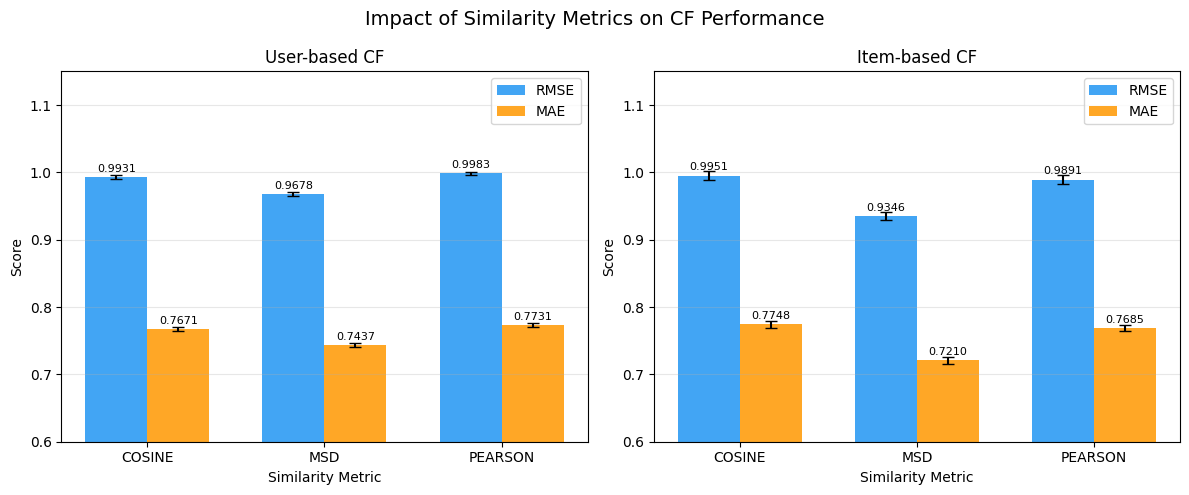

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Impact of Similarity Metrics on CF Performance', fontsize=14)

x = np.arange(len(similarity_metrics))
width = 0.35
colors = {'RMSE': '#2196F3', 'MAE': '#FF9800'}

for ax, cf_type in zip(axes, ['User-based CF', 'Item-based CF']):
    rmse_vals = [sim_results[cf_type][s]['RMSE_mean'] for s in similarity_metrics]
    mae_vals  = [sim_results[cf_type][s]['MAE_mean']  for s in similarity_metrics]
    rmse_stds = [sim_results[cf_type][s]['RMSE_std']  for s in similarity_metrics]
    mae_stds  = [sim_results[cf_type][s]['MAE_std']   for s in similarity_metrics]

    bars1 = ax.bar(x - width/2, rmse_vals, width, label='RMSE', color=colors['RMSE'], alpha=0.85, yerr=rmse_stds, capsize=4)
    bars2 = ax.bar(x + width/2, mae_vals,  width, label='MAE', color=colors['MAE'],  alpha=0.85, yerr=mae_stds,  capsize=4)

    # Value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(cf_type)
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in similarity_metrics])
    ax.set_xlabel('Similarity Metric')
    ax.set_ylabel('Score')
    ax.set_ylim(0.6, 1.15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Answer: Yes, the impact of the three similarity metrics on User-based CF is consistent with their impact on Item-based CF. In both cases, MSD produces 
the best performance under both RMSE and MAE, Cosine ranks second, and Pearson performs worst. The ranking MSD > Cosine > Pearson is true for both
CF types across both evaluation metrics.

This consistency makes sense. MSD (Mean Squared Difference) mainly applies for the magnitude of rating differences between users or items, 
which is great for just using rating data on a numerical scale. Cosine similarity finds directional agreement in rating patterns but
ignores the scale of differences. Pearson correlation looks for individual rating biases but it is more sensitive to sparse data. With 671
users and 9,066 movies, the rating matrix is highly sparse, which does not work in favor for Pearson's reliability.

Also, the performance gap between MSD and the other two metrics is bigger for Item-based CF (RMSE gap of ~0.06) than for User-based CF (RMSE gap of ~0.03), 
which shows that MSD's magnitude-aware similarity feature works well for Item-based CF.

### Task 2.4: Examine how the number of neighbors impacts the performances of User based Collaborative Filtering and Item based Collaborative Filtering. Plot your results.  


In [20]:
# k = number of neighbors to test
k_values = [5, 10, 20, 30, 40, 50, 60, 80, 100]

neighbor_results = {
    'User-based CF': {'RMSE': [], 'MAE': [], 'RMSE_std': [], 'MAE_std': []},
    'Item-based CF': {'RMSE': [], 'MAE': [], 'RMSE_std': [], 'MAE_std': []},
}

# running CV for each K - model combination
# using MSD here since it was the best similarity metric from Task 2.3
for k in k_values:
    for cf_type, user_based in [('User-based CF', True), ('Item-based CF', False)]:
        print(f"Running {cf_type} with K={k}")
        model = KNNBasic(k=k, sim_options={'name': 'msd', 'user_based': user_based})
        result = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=kf, verbose=False)
        neighbor_results[cf_type]['RMSE'].append(result['test_rmse'].mean())
        neighbor_results[cf_type]['MAE'].append(result['test_mae'].mean())
        neighbor_results[cf_type]['RMSE_std'].append(result['test_rmse'].std())
        neighbor_results[cf_type]['MAE_std'].append(result['test_mae'].std())

Running User-based CF with K=5
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Running Item-based CF with K=5
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Running User-based CF with K=10
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity m

In [21]:
print("\nTask 2.4: Neighbor Count Comparison")
for cf_type in ['User-based CF', 'Item-based CF']:
    print(f"\n{cf_type}:")
    print(f"  {'K':<8} {'Avg RMSE':>10} {'Avg MAE':>10}")
    print(f"  {'-'*30}")
    for i, k in enumerate(k_values):
        rmse = neighbor_results[cf_type]['RMSE'][i]
        mae  = neighbor_results[cf_type]['MAE'][i]
        print(f"  {k:<8} {rmse:>10.4f} {mae:>10.4f}")


Task 2.4: Neighbor Count Comparison

User-based CF:
  K          Avg RMSE    Avg MAE
  ------------------------------
  5            0.9863     0.7548
  10           0.9650     0.7380
  20           0.9626     0.7377
  30           0.9652     0.7408
  40           0.9678     0.7437
  50           0.9699     0.7460
  60           0.9715     0.7478
  80           0.9740     0.7506
  100          0.9756     0.7522

Item-based CF:
  K          Avg RMSE    Avg MAE
  ------------------------------
  5            1.0220     0.7904
  10           0.9750     0.7545
  20           0.9476     0.7326
  30           0.9385     0.7246
  40           0.9346     0.7210
  50           0.9328     0.7194
  60           0.9318     0.7185
  80           0.9313     0.7178
  100          0.9318     0.7182


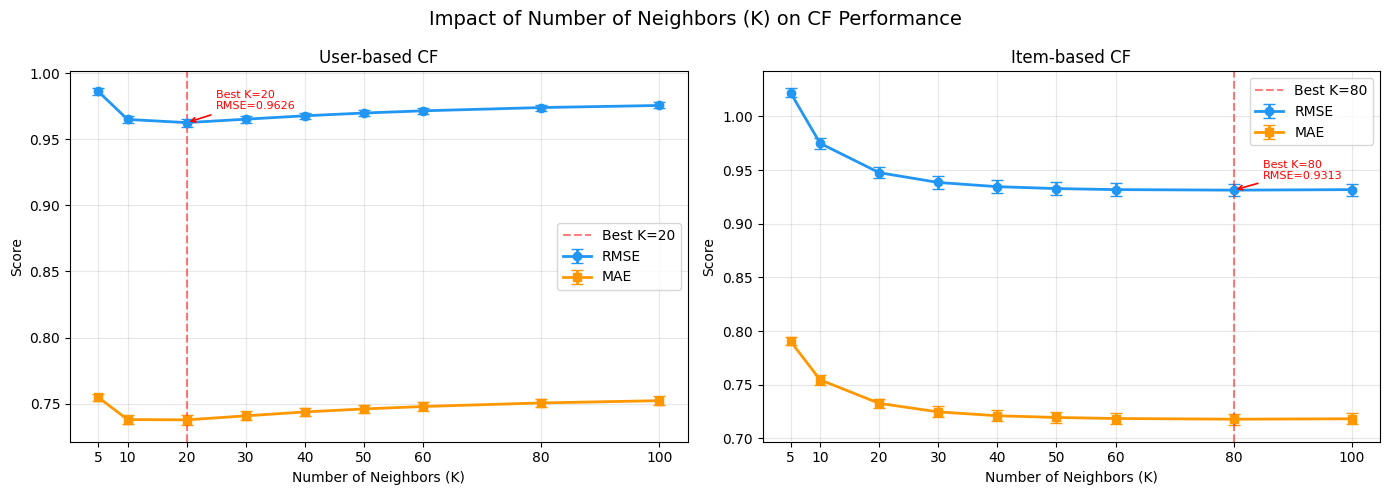

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact of Number of Neighbors (K) on CF Performance', fontsize=14)

for ax, cf_type in zip(axes, ['User-based CF', 'Item-based CF']):
    rmse_vals = neighbor_results[cf_type]['RMSE']
    mae_vals  = neighbor_results[cf_type]['MAE']
    rmse_stds = neighbor_results[cf_type]['RMSE_std']
    mae_stds  = neighbor_results[cf_type]['MAE_std']

    ax.errorbar(k_values, rmse_vals, yerr=rmse_stds, marker='o', label='RMSE', color='#2196F3', capsize=4, linewidth=2, markersize=6)
    ax.errorbar(k_values, mae_vals, yerr=mae_stds, marker='s', label='MAE', color='#FF9800', capsize=4, linewidth=2, markersize=6)

    # highlight best K for RMSE
    best_k_idx = np.argmin(rmse_vals)
    best_k     = k_values[best_k_idx]
    best_rmse  = rmse_vals[best_k_idx]
    ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.5, label=f'Best K={best_k}')
    ax.annotate(f'Best K={best_k}\nRMSE={best_rmse:.4f}', xy=(best_k, best_rmse), xytext=(best_k + 5, best_rmse + 0.01), fontsize=8, color='red', arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

    ax.set_title(cf_type)
    ax.set_xlabel('Number of Neighbors (K)')
    ax.set_ylabel('Score')
    ax.set_xticks(k_values)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Answer: The number of neighbors impacts User-based CF and Item-based CF differently, showing fundamental difference in their similarity spaces.

- For User-based CF, performance improves quickly as K increases from 5 to 20,
then degrades gradually beyond K=20. This is because too few neighbors introduces 
high variance (predictions rely on very few, potentially noisy users), while too 
many neighbors over-smooths predictions by incorporating dissimilar users. The 
optimal K is small (K=20) because with only 671 users, the pool of genuinely 
similar neighbors is limited.

- For Item-based CF, performance improves steadily as K increases and plateaus
around K=80, with no sign of degradation even at K=100. I think this is due to
the item space being much larger (9,066 items), meaning there are more
genuinely similar neighbors available at higher K values. The model continues
to get better from additional neighbors without suffering from over-smoothing.

Overall, Item-based CF is less sensitive to the choice of K and more stable
across a wide range of neighbor counts, while User-based CF requires more
careful tuning of K to avoid performance degradation.

### Task 2.5: Identify the best number of neighbor (denoted by K) for User/Item based collaborative filtering in terms of RMSE.

In [24]:
# getting best K values for each CF type based on lowest RMSE
best_k_results = {}

for cf_type in ['User-based CF', 'Item-based CF']:
    rmse_vals = neighbor_results[cf_type]['RMSE']
    mae_vals  = neighbor_results[cf_type]['MAE']
    best_idx  = np.argmin(rmse_vals)
    best_k    = k_values[best_idx]
    best_rmse = rmse_vals[best_idx]
    best_mae  = mae_vals[best_idx]
    best_k_results[cf_type] = {
        'best_k':    best_k,
        'best_rmse': best_rmse,
        'best_mae':  best_mae,
    }

In [27]:
print("Task 2.5: Best K for UserCF and ItemCF\n")
print(f"{'CF Type':<20} {'Best K':>8} {'RMSE':>10} {'MAE':>10}")
print("-" * 52)
for cf_type, r in best_k_results.items():
    print(f"{cf_type:<20} {r['best_k']:>8} {r['best_rmse']:>10.4f} {r['best_mae']:>10.4f}")

user_best_k = best_k_results['User-based CF']['best_k']
item_best_k = best_k_results['Item-based CF']['best_k']
same_k = user_best_k == item_best_k
print(f"\nBest K for User-based CF : {user_best_k}")
print(f"Best K for Item-based CF : {item_best_k}")
print(f"Same best K             : {'Yes' if same_k else 'No'}")

Task 2.5: Best K for UserCF and ItemCF

CF Type                Best K       RMSE        MAE
----------------------------------------------------
User-based CF              20     0.9626     0.7377
Item-based CF              80     0.9313     0.7178

Best K for User-based CF : 20
Best K for Item-based CF : 80
Same best K             : No


Answer: The best K for User-based CF and Item-based CF are NOT the same.

- User-based CF performs best at K=20 (RMSE=0.9626, MAE=0.7377). Beyond this
point, adding more neighbors hurts performance as predictions get diluted by
dissimilar users. With only 671 users in the dataset, the pool of genuinely
similar neighbors is small, so a lower K is optimal.

- Item-based CF performs best at K=80 (RMSE=0.9313, MAE=0.7178). The much
larger item space (9,066 items) means there are more genuinely similar
neighbors available, allowing the model to benefit from a larger neighborhood
without over-smoothing. The curve also plateaus gracefully, K=60, 80, and
100 all produce very similar RMSE values (~0.931–0.932), suggesting Item-based
CF is robust to K in this range.

- The difference in optimal K is directly connected to the dataset:
fewer users means User-based CF saturates at a small K, while the much richer
item space allows Item-based CF to leverage a larger neighborhood effectively.
In practice, Item-based CF with K=80 is the best overall configuration,
achieving the lowest RMSE (0.9313) of any K or CF type combination tested.